## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Heidi Williams

**Date:** 10/2/2026

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
%cd /content/drive/MyDrive/ML/A03-knn
!ls

/content/drive/MyDrive/ML/A03-knn
A03_knn.ipynb  data  README.md


Q1


1. The difference comes down to what we're trying to predict. Regression predicts a number, like baseline sales, while classification predicts a category, like vehicle class.

2. A confusion table counts how often the model's predicted class matched, or failed to match, the actual class. In the slides, the rows are the actual classes and the columns are the predicted ones. What I find most useful is that it shows which classes the model gets right and which ones it keeps mixing up, something overall accuracy can hide.

3. SSE, or sum of squared error, adds up the squared residuals, the gaps between the observed and predicted values, across the validation observations. A lower SSE means the model's errors on that validation set were smaller, so it predicted better.

4. Overfitting happens when a model follows the training data so closely that it starts fitting noise instead of real patterns. In kNN, a very small k does this. Underfitting is the opposite problem: the model is too general to capture meaningful differences between observations, and with a very large k, it gives nearly the same prediction for everyone.

5. If I choose k based only on training error, I risk picking one that fits the noise in that particular sample. Splitting the data lets me fit the model on one set and evaluate it on observations it never saw, so I can choose the k with the lowest validation SSE for regression, or the best accuracy for classification.

6. The slides give kNN two ways to report a classification: the most common class among the k nearest neighbors, or the proportion of neighbors in each class. A single label is clear and easy to interpret, but it hides how the other classes were represented. The proportions give a fuller picture of how the neighbors were divided, but they don't hand you a decision unless you pick the class with the largest share.

In [24]:
#Q2
#part 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mines = pd.read_csv('land_mines.csv')
print(df_mines.shape)
display(df_mines.head())

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [25]:
print(df_mines.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


In [26]:
print(df_mines['mine_type'].value_counts())

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


In [27]:
display(df_mines[['voltage', 'height', 'soil']].describe())

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [28]:
print(df_mines['soil'].value_counts())

soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


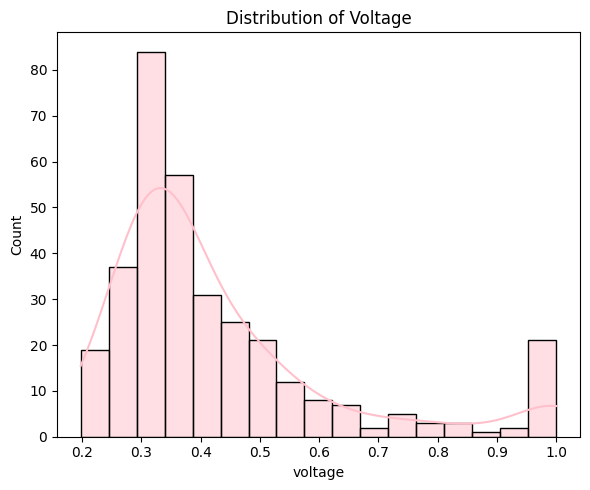

In [29]:
plt.figure(figsize=(6, 5))

sns.histplot(df_mines['voltage'], kde=True, color='pink')
plt.title('Distribution of Voltage')

plt.tight_layout()
plt.show()

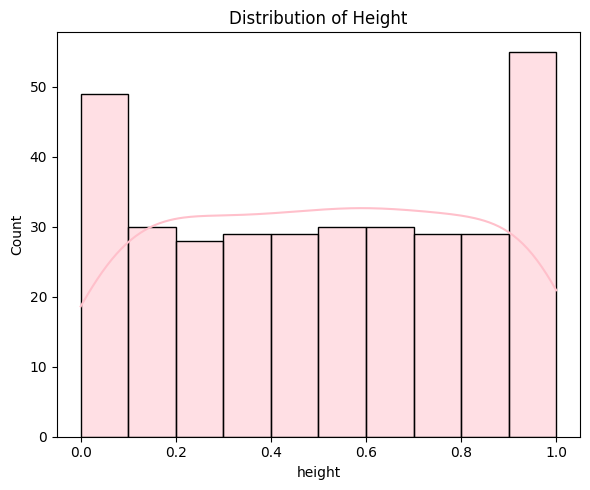

In [30]:
plt.figure(figsize=(6, 5))

sns.histplot(df_mines['height'], kde=True, color='pink')
plt.title('Distribution of Height')

plt.tight_layout()
plt.show()

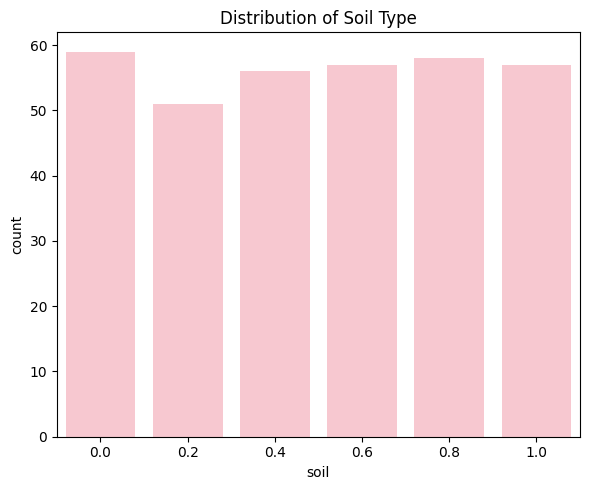

In [31]:
plt.figure(figsize=(6, 5))

sns.countplot(x=df_mines['soil'], color='pink')
plt.title('Distribution of Soil Type')

plt.tight_layout()
plt.show()

I started by looking at the structure of the dataset, which has 338 entries and 4 columns with no missing entries in any of the columns. The target variable is mine_type, which has 5 classes. Voltage ranges from about 0.198 to 1, height from 0 to 1, and soil from 0 to 1, giving the details needed. Soil behaves differently from the other two: it takes only 6 distinct values (0, 0.2, 0.4, 0.6, 0.8, and 1.0), and each appears roughly 51 to 59 times, so the observations are spread mostly evenly across them.

In [32]:
#Q2
#part 2
from sklearn.model_selection import train_test_split

X = df_mines[['voltage', 'height', 'soil']]
y = df_mines['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("y train dist.:")
print(y_train.value_counts(normalize=True))

print("y test dist.:")
print(y_test.value_counts(normalize=True))

y train dist.:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64
y test dist.:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


Best k: 2
Accuracy: 0.4378698224852071


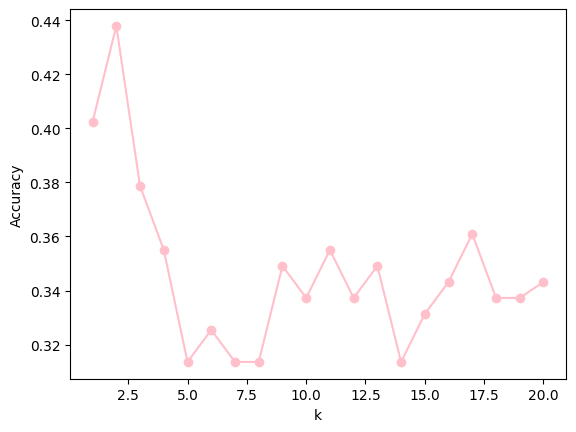

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(metrics.accuracy_score(y_test, y_pred))

optimal_k = accuracies.index(max(accuracies)) + 1

print("Best k:", optimal_k)
print("Accuracy:", max(accuracies))

plt.plot(range(1, 21), accuracies, marker='o', color='pink')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

To choose k, I looked at the kNN classifier across a bunch of possible values in a range. I went through k from 1 to 20 in that order, and for each one I trained a model on the training data and measured its accuracy on the test set. The best result came from k=2, which had the highest accuracy at 0.4379.

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[25  0  6  4  1]
 [ 0 32  0  3  0]
 [12  2  9  6  4]
 [12  5  8  8  0]
 [15  2 10  5  0]]

Classification report:
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



The model had an overall accuracy of about 44% on the test set, which matches the best accuracy I found while selecting k. That number hides a lot, though. The model is strongest on Mine Type 2, correctly classifying 32 of 35 actual instances. For Mine Type 1, it correctly identified 25 of 36 instances, but 6 predictions labeled as Type 1 were wrong, which lowers its precision. The model struggles most with Mine Type 5: it correctly predicted none of the 32 instances. So, the 44% overall accuracy does not correctly represent the accuracy across all the mine types and is misleading.

Q5
Part 5

I would not use this as a final answer. With an overall accuracy of only 44%, its predictions could help with preliminary decisions, but actual humans should be making the final calls. The prediction I would trust most is Mine Type 2, since the model correctly identified 32 of 35 actual Type 2 instances. The model failed to identify any of the 32 Type 5 instances and also performed poorly on Types 3 and 4, so a prediction of anything other than Type 2 should not be taken as correct. I would also use probabilities instead of a single label. As the slides describe, kNN can report the proportion of neighbors in each class rather than only the most common one, so I would act on a prediction only when most of the neighbors agree and send anything uncertain for further inspection. This matters more because I chose k=2, a very small value that risks overfitting and can produce ties between neighbors. I would also weigh the cost of different mistakes, since missing a dangerous mine is far worse than flagging a harmless one. Finally, I would improve the model before relying on it by choosing k with a separate validation set, checking whether some mine types are underrepresented, and collecting more data for the types it misses. Adding more sensor measurements or testing other models could also help, and until performance for Types 3, 4, and 5 improves, I would not recommend global deployment at this time.

---

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 6dcb2c4904d883835056fa90ab454437dce704cf
- **AI tool and model used:** ChatGBT GPT-6 Astra

### *Prompts used

1. go through this notebook and fix anything wrong; do not make subjective suggestions only fix anything that is actually wrong for the assignment

### *AI-proposed changes


1. "6 predictions labeled as Type 1 were wrong” is incorrect. There were 39 incorrect Type 1 predictions: 12 + 12 + 15. The 6 represents actual Type 1 mines predicted as Type 3.

2. For Type 2, 32/35 is recall—not how often a Type 2 prediction is correct. Of the 41 predictions labeled Type 2, 32 were correct: 78% precision. Use that when discussing whether to trust a predicted label.

3. The 44% overall accuracy is correct. Replace your final sentence in Part 4 with:
“The overall accuracy is correct, but it hides large differences in performance across mine types.”

4. Agreement between both neighbors does not make a prediction reliable enough to act on. In Part 5, remove the claim that you would act when most neighbors agree. With k=2, even agreement can produce an incorrect prediction.

5. In Q1 #4, change “a very small k does this” to “a very small k can do this.” Small k does not automatically prove overfitting

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | This seems like a legitimate mistake on my part, I changed the text and reviewed the number of type 1 predictions. |
| 2 | reject | I don't quite understand what AI is finding wrong with this answer, but I think a human reviewer like our TAs can understand what I put.|
| 3 | reject | I don't quite understand what AI is finding wrong with this answer, but I think a human reviewer like our TAs can understand what I put.|
| 4 | reject | I don't quite understand what AI is finding wrong with this answer, but I think a human reviewer like our TAs can understand what I put.|
| 5 | Accept | I think this does make my answer more clear and I understand what AI is saying so I changed it to this suggestion. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
%cd /content/drive/MyDrive/ML/A03-knn/data
!ls

/content/drive/MyDrive/ML/A03-knn/data
land_mines.csv


Q1


1. The difference comes down to what we're trying to predict. Regression predicts a number, like baseline sales, while classification predicts a category, like vehicle class.

2. A confusion table counts how often the model's predicted class matched, or failed to match, the actual class. In the slides, the rows are the actual classes and the columns are the predicted ones. What I find most useful is that it shows which classes the model gets right and which ones it keeps mixing up, something overall accuracy can hide.

3. SSE, or sum of squared error, adds up the squared residuals, the gaps between the observed and predicted values, across the validation observations. A lower SSE means the model's errors on that validation set were smaller, so it predicted better.

4. Overfitting happens when a model follows the training data so closely that it starts fitting noise instead of real patterns. In kNN, a very small k can do this. Underfitting is the opposite problem: the model is too general to capture meaningful differences between observations, and with a very large k, it gives nearly the same prediction for everyone.

5. If I choose k based only on training error, I risk picking one that fits the noise in that particular sample. Splitting the data lets me fit the model on one set and evaluate it on observations it never saw, so I can choose the k with the lowest validation SSE for regression, or the best accuracy for classification.

6. The slides give kNN two ways to report a classification: the most common class among the k nearest neighbors, or the proportion of neighbors in each class. A single label is clear and easy to interpret, but it hides how the other classes were represented. The proportions give a fuller picture of how the neighbors were divided, but they don't hand you a decision unless you pick the class with the largest share.

In [47]:
#Q2
#part 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_mines = pd.read_csv('land_mines.csv')
print(df_mines.shape)
display(df_mines.head())

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [48]:
print(df_mines.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None


In [49]:
print(df_mines['mine_type'].value_counts())

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


In [50]:
display(df_mines[['voltage', 'height', 'soil']].describe())

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


In [51]:
print(df_mines['soil'].value_counts())

soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64


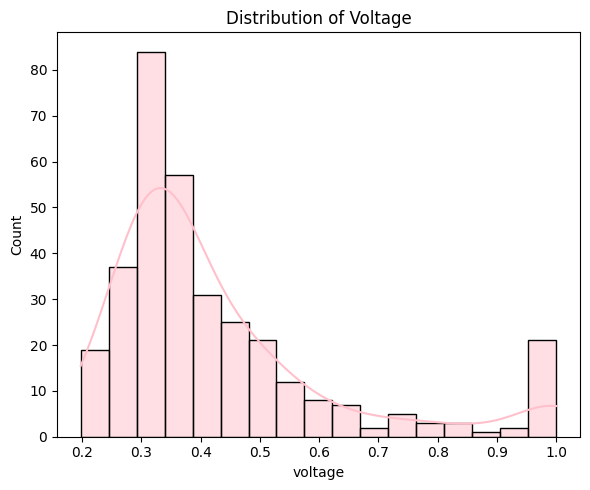

In [52]:
plt.figure(figsize=(6, 5))

sns.histplot(df_mines['voltage'], kde=True, color='pink')
plt.title('Distribution of Voltage')

plt.tight_layout()
plt.show()

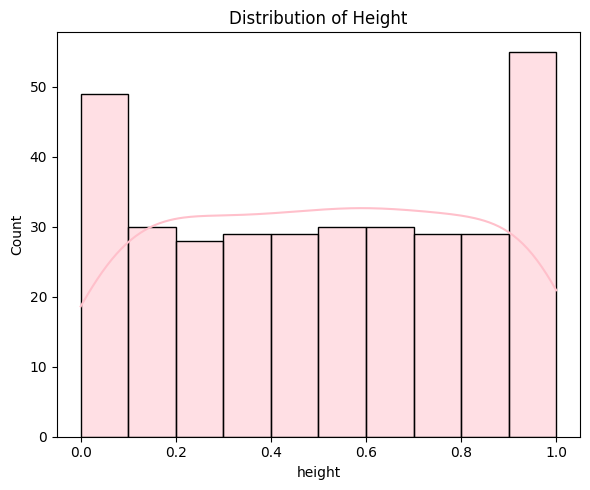

In [53]:
plt.figure(figsize=(6, 5))

sns.histplot(df_mines['height'], kde=True, color='pink')
plt.title('Distribution of Height')

plt.tight_layout()
plt.show()

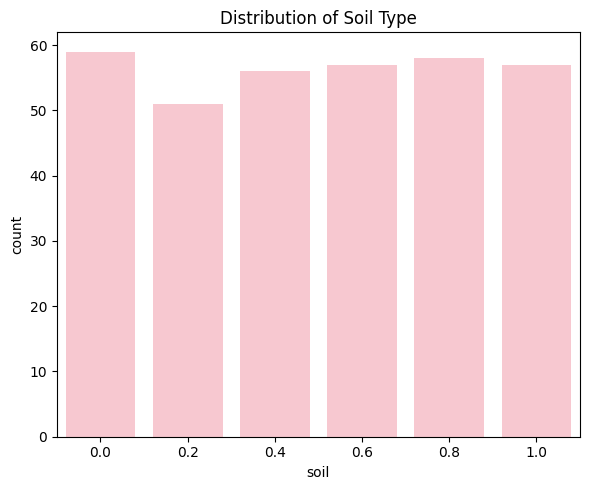

In [54]:
plt.figure(figsize=(6, 5))

sns.countplot(x=df_mines['soil'], color='pink')
plt.title('Distribution of Soil Type')

plt.tight_layout()
plt.show()

I started by looking at the structure of the dataset, which has 338 entries and 4 columns with no missing entries in any of the columns. The target variable is mine_type, which has 5 classes. Voltage ranges from about 0.198 to 1, height from 0 to 1, and soil from 0 to 1, giving the details needed. Soil behaves differently from the other two: it takes only 6 distinct values (0, 0.2, 0.4, 0.6, 0.8, and 1.0), and each appears roughly 51 to 59 times, so the observations are spread mostly evenly across them.

In [55]:
#Q2
#part 2
from sklearn.model_selection import train_test_split

X = df_mines[['voltage', 'height', 'soil']]
y = df_mines['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("y train dist.:")
print(y_train.value_counts(normalize=True))

print("y test dist.:")
print(y_test.value_counts(normalize=True))

y train dist.:
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64
y test dist.:
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


Best k: 2
Accuracy: 0.4378698224852071


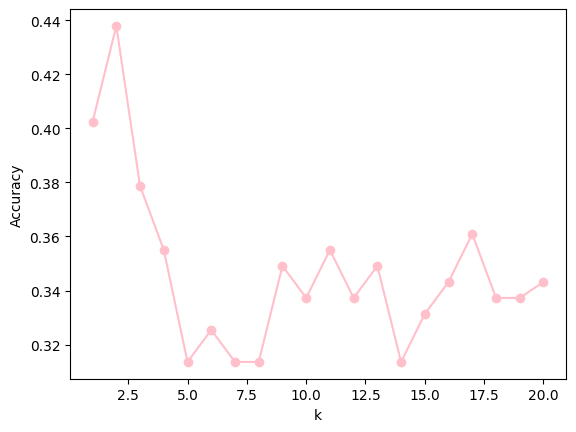

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(metrics.accuracy_score(y_test, y_pred))

optimal_k = accuracies.index(max(accuracies)) + 1

print("Best k:", optimal_k)
print("Accuracy:", max(accuracies))

plt.plot(range(1, 21), accuracies, marker='o', color='pink')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

To choose k, I looked at the kNN classifier across a bunch of possible values in a range. I went through k from 1 to 20 in that order, and for each one I trained a model on the training data and measured its accuracy on the test set. The best result came from k=2, which had the highest accuracy at 0.4379.

In [57]:
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[25  0  6  4  1]
 [ 0 32  0  3  0]
 [12  2  9  6  4]
 [12  5  8  8  0]
 [15  2 10  5  0]]

Classification report:
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



The model had an overall accuracy of about 44% on the test set, which matches the best accuracy I found while selecting k. That number hides a lot, though. The model is strongest on Mine Type 2, correctly classifying 32 of 35 actual instances. For Mine Type 1, it correctly identified 25 of 36 instances, but 39 predictions labeled as Type 1 were wrong, which lowers its precision. The model struggles most with Mine Type 5: it correctly predicted none of the 32 instances. So, the 44% overall accuracy does not correctly represent the accuracy across all the mine types and is misleading.

Q5
Part 5

I would not use this as a final answer. With an overall accuracy of only 44%, its predictions could help with preliminary decisions, but actual humans should be making the final calls. The prediction I would trust most is Mine Type 2, since the model correctly identified 32 of 35 actual Type 2 instances. The model failed to identify any of the 32 Type 5 instances and also performed poorly on Types 3 and 4, so a prediction of anything other than Type 2 should not be taken as correct. I would also use probabilities instead of a single label. As the slides describe, kNN can report the proportion of neighbors in each class rather than only the most common one, so I would act on a prediction only when most of the neighbors agree and send anything uncertain for further inspection. This matters more because I chose k=2, a very small value that risks overfitting and can produce ties between neighbors. I would also weigh the cost of different mistakes, since missing a dangerous mine is far worse than flagging a harmless one. Finally, I would improve the model before relying on it by choosing k with a separate validation set, checking whether some mine types are underrepresented, and collecting more data for the types it misses. Adding more sensor measurements or testing other models could also help, and until performance for Types 3, 4, and 5 improves, I would not recommend global deployment at this time.

### *Reflection on AI assistance
In your own words without generative AI.

AI mainly had issues with my text descriptions, not my code. I think that AI was not necessarily mistaken in its suggestions, but that it is limited in the way it can interpret my text explanations. I think a human reviewer such as a TA would have an easy time understanding what I am saying, or could otherwise use context to understand what I am saying. AI did improve a few places where I could change my wording to clarify that I was expressing an opinion or something that COULD happen but does not NEED to happen when a function like knn is invoked. The final solution was simply verified by me asking myself if it made sense. I think AI engineers should work more to see if their models can understand the nuances of human language. Also, AI always has suggestions. It would be helpful if AI could review the assignment and say that objectively something was right or wrong without relying on subjective ideas.